In [1]:
import pandas as pd

from pathlib import Path

import smtplib, ssl

### Load Scores

In [2]:
exercise_path = Path("course_directory/ads_exercise")
output_path = Path("total_score")

In [3]:
scores = pd.read_csv(exercise_path.joinpath("grades.csv"))
scores.head()

,assignment,duedate,timestamp,student_id,last_name,first_name,email,raw_score,late_submission_penalty,score,max_score
0,0-setup,NaN,NaN,lucaabel,NaN,NaN,NaN,0.0,0.0,0.0,1.0
1,0-setup,NaN,NaN,A-Pauline,NaN,NaN,NaN,1.0,0.0,1.0,1.0
2,0-setup,NaN,NaN,Aastha-Thapaliya,NaN,NaN,NaN,0.0,0.0,0.0,1.0
3,0-setup,NaN,NaN,Abhijna36,NaN,NaN,NaN,1.0,0.0,1.0,1.0
4,0-setup,NaN,NaN,AdarShachath,NaN,NaN,NaN,1.0,0.0,1.0,1.0


In [4]:
score_long = scores.set_index(["student_id", "assignment"]).sort_index()
score_long

duedate  timestamp  last_name  first_name  \
student_id assignment                                                      
A-Pauline  0-setup                 NaN        NaN        NaN         NaN   
           1-python-basics-I       NaN        NaN        NaN         NaN   
           2-python-basics-II      NaN        NaN        NaN         NaN   
           3-control-flow          NaN        NaN        NaN         NaN   
           4-dicts-classes         NaN        NaN        NaN         NaN   
...                                ...        ...        ...         ...   
zubejda    5-numpy-scipy           NaN        NaN        NaN         NaN   
           6-pandas                NaN        NaN        NaN         NaN   
           7-statistics            NaN        NaN        NaN         NaN   
           8-visualization         NaN        NaN        NaN         NaN   
           9-ml                    NaN        NaN        NaN         NaN   

                               email  raw_score  late_submission_penalty  \
student_id assignment                                                      
A-Pauline  0-setup               NaN        1.0                      0.0   
           1-python-basics-I     NaN        8.0                      0.0   
           2-python-basics-II    NaN        7.5                      0.0   
           3-control-flow        NaN        0.0                      0.0   
           4-dicts-classes       NaN        0.0                      0.0   
...                              ...        ...                      ...   
zubejda    5-numpy-scipy         NaN        3.0                      0.0   
           6-pandas              NaN       12.0                      0.0   
           7-statistics          NaN        3.0                      0.0   
           8-visualization       NaN        9.0                      0.0   
           9-ml                  NaN        0.0                      0.0   

                               score  max_score  
student_id assignment                            
A-Pauline  0-setup               1.0        1.0  
           1-python-basics-I     8.0        8.0  
           2-python-basics-II    7.5       10.0  
           3-control-flow        0.0       10.0  
           4-dicts-classes       0.0       13.0  
...                              ...        ...  
zubejda    5-numpy-scipy         3.0       10.0  
           6-pandas             12.0       12.0  
           7-statistics          3.0       11.0  
           8-visualization       9.0       11.0  
           9-ml                  0.0       19.0  

[610 rows x 9 columns]

In [5]:
sum_points = score_long["score"].unstack("assignment").sum(axis=1)
sum_points

student_id
A-Pauline           16.5
Aastha-Thapaliya     0.0
Abhijna36           64.5
AdarShachath        43.0
ArefehRh             0.0
                    ... 
sophajey             0.0
taba-luca           41.0
teenanandwani       76.0
vijaygowda95         0.0
zubejda             69.0
Length: 61, dtype: float64

In [12]:
score_long.xs("AhmedSofan10", level="student_id")

In [6]:
max_score = score_long.xs(score_long.index[0][0], level="student_id")["max_score"].sum() # select the first student
max_score

105.0

In [8]:
# set this manually, when the score is not right
max_score = 86.0

In [10]:
percentage = (sum_points / max_score) * 100 
percentage[percentage > 100] = 100
percentage = percentage.sort_values(ascending=False)

<Axes: >

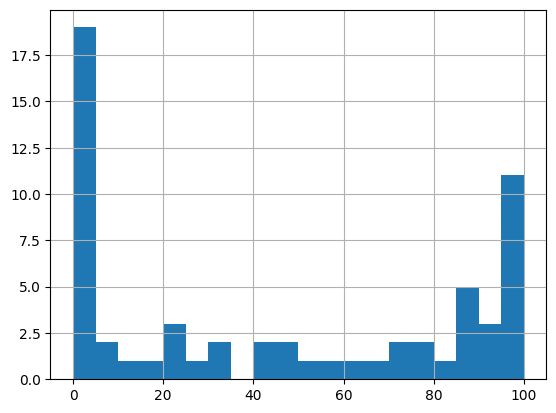

In [11]:
percentage.hist(bins=20)

In [12]:
import time

semester = "SoSe_24"

# export csv
timestr = time.strftime("%Y%m%d-%H%M%S")
percentage.to_csv(output_path.joinpath(semester+"-"+timestr+".csv"))

In [13]:
idm_list = pd.read_csv("course_directory/classroom_roster.csv").loc[:,["identifier", "github_username"]]
idm_list

,identifier,github_username
0,ac13atok,mdtrch
1,ac28azeg,Kittykat002
2,ac41ycar,NaN
3,af96ymek,NaN
4,ag46abiw,NurObj
...,...,...
123,za41xuki,FionaBeck
124,ze30qyse,parisa7103
125,ze61nido,NaN
126,zu33ujwu,han-bur


In [14]:
idm_list.set_index("github_username", inplace=True)
idm_list.index.name = "student_id"

In [15]:
idm_list

,identifier
student_id,
mdtrch,ac13atok
Kittykat002,ac28azeg
NaN,ac41ycar
NaN,af96ymek
NurObj,ag46abiw
...,...
FionaBeck,za41xuki
parisa7103,ze30qyse
NaN,ze61nido


In [16]:
# join percentage and idm_list

total = pd.DataFrame(percentage, columns=["score_percent"]).join(idm_list, how="inner")
total

,score_percent,identifier
student_id,,
A-Pauline,19.186047,wo70roru
Aastha-Thapaliya,0.000000,qo24gufe
Abhijna36,75.000000,yn19ufid
AdarShachath,50.000000,ok62ihoc
ArefehRh,0.000000,ju47kato
...,...,...
sophajey,0.000000,gu75give
taba-luca,47.674419,cy73sela
teenanandwani,88.372093,ra27foxa


In [17]:
# drop all rows with identifier length > 8 

total.drop(total[total['identifier'].str.len() > 8].index, inplace = True)

In [18]:
total

,score_percent,identifier
student_id,,
A-Pauline,19.186047,wo70roru
Aastha-Thapaliya,0.000000,qo24gufe
Abhijna36,75.000000,yn19ufid
AdarShachath,50.000000,ok62ihoc
ArefehRh,0.000000,ju47kato
DARREN-2000,20.930233,sa01juwe
ElisabethMeier,55.813953,se67myvy
Farhad-Valizadegan,0.000000,wi93xyle
FionaBeck,75.581395,za41xuki


In [19]:
total = total.reset_index().set_index("identifier").drop("student_id", axis=1).sort_index()
total

,score_percent
identifier,
ac13atok,10.465116
ac28azeg,1.162791
ag46abiw,0.000000
as73isud,99.418605
at74ynyg,2.906977
cu40xetu,88.953488
cy73sela,47.674419
ec40odyf,40.697674
ej80ogyg,0.000000


In [20]:
total.to_csv(output_path.joinpath("2024_after_8.csv"))

In [18]:
mails = pd.read_csv('studon_export/mails/mails.csv')
mails = mails[["Login", "E-Mail", "First Name", "Last Name"]]
mails

In [19]:
# rename columns
mails = mails.rename({"Login":"identifier", "E-Mail":"email", "First Name":"first_name", "Last Name":"last_name"}, axis=1).set_index("identifier")
mails

In [20]:
email_result = total.join(mails, how="inner")
email_result

In [29]:
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText

import time

In [33]:
# write mail
smtp_server = "smtp.gmail.com"
port = 587  # For starttls
sender_email = "dipsylab@gmail.com"
password = "eestjmljnibjgesu"

# Create a secure SSL context
context = ssl.create_default_context()

# Try to log in to server and send email
try:
    server = smtplib.SMTP(smtp_server,port)
    server.ehlo() # Can be omitted
    server.starttls(context=context) # Secure the connection
    server.ehlo() # Can be omitted
    server.login(sender_email, password)
    
    # send mail here
    for identifier, student in email_result[:5].iterrows():
        message = MIMEMultipart()

        message["From"] = sender_email
        message["To"] = student.email
        message["Subject"] = "ADS Exercise Result"

        # Add body to email
        
        message.attach(MIMEText(f"Hi {student.first_name}, \n\n your total score is {round(student.score_percent, 1)} %.  \n\n Best regards, \n ADS Team", "plain"))
        
        message.attach(MIMEText(f"\n\n This message was automatically generated. Please do not reply to this email.", "plain")

        server.sendmail(sender_email, "luca.abel@fau.de", message.as_string())
        #wait for 1 second

        time.sleep(1)    
    
except Exception as e:
    # Print any error messages to stdout
    print(e)
finally:
    server.quit() 